# 07. Population Typology — Building-Level Age Profiles

Assign age-specific population estimates to residential buildings in Nørrebro, framed around **health-relevant age groups** for active transport interventions.

**Core idea:** For each building, estimate the plausible range (low/mid/high) of people in each age group who could benefit from or be affected by walking/cycling infrastructure.

**Data Sources:**
- `data/integrated/norrebro_buildings.gpkg` — Building footprints with BBR attributes (residential area, floors, use type)
- `data/processed/norrebro_neighbourhoods_population.csv` — Population by 20 five-year age bands per sub-neighbourhood
- `data/processed/norrebro_neighbourhoods_dwellings.csv` — Dwelling units by type and household size per sub-neighbourhood
- `data/processed/norrebro_boundary.gpkg` — Sub-neighbourhood geometries

**Health-relevant age groups:**

| Group | Ages | Why distinct |
| --- | --- | --- |
| Children | 0–14 | Dependent — not independent active travelers |
| Young adults | 15–29 | High mobility, student housing concentrations |
| Working age | 30–64 | Primary commuting beneficiaries |
| Older adults | 65–79 | Reduced speed (~1.0–1.2 m/s), high health benefit per unit of activity |
| Very elderly | 80+ | Limited mobility (~0.6–0.9 m/s), highest benefit but smallest catchments |

In [1]:
import sys
from pathlib import Path

# Add project root to sys.path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import numpy as np
import contextily as ctx

from src.visualization import style

style.apply_style()

## 0. Load Data

In [2]:
# Paths
data_dir = project_root / "data"
buildings_path = data_dir / "integrated" / "norrebro_buildings.gpkg"
pop_path = data_dir / "processed" / "norrebro_neighbourhoods_population.csv"
dwell_path = data_dir / "processed" / "norrebro_neighbourhoods_dwellings.csv"
boundary_path = data_dir / "processed" / "norrebro_boundary.gpkg"

# Load
gdf_buildings = gpd.read_file(buildings_path, layer="buildings")
df_pop = pd.read_csv(pop_path)
df_dwell = pd.read_csv(dwell_path)
gdf_hoods = gpd.read_file(boundary_path, layer="neighbourhoods")

# Add gm_id to neighbourhoods (index + 1, matching config.GM_ID_MAPPING)
gdf_hoods["gm_id"] = gdf_hoods.index + 1

print(f"Buildings:       {len(gdf_buildings):,} footprints")
print(f"Population:      {len(df_pop)} rows, {df_pop['people'].sum():,} total people")
print(f"Dwellings:       {len(df_dwell)} rows")
print(f"Neighbourhoods:  {len(gdf_hoods)}")

Buildings:       5,915 footprints
Population:      100 rows, 79,753 total people
Dwellings:       175 rows
Neighbourhoods:  10


In [3]:
# dedup neighbourgoods df
gdf_hoods = gdf_hoods.drop_duplicates(
    subset=["neighbourhood_name", "geometry"], keep="first"
)
print(f"Neighbourhoods:  {len(gdf_hoods)}")


Neighbourhoods:  5


In [4]:
# Filter to residential buildings
gdf_res = gdf_buildings[gdf_buildings["residential_area_m2"] > 0].copy()
print(f"Residential buildings: {len(gdf_res):,} (of {len(gdf_buildings):,} total)")
print(f"Total residential area: {gdf_res['residential_area_m2'].sum():,.0f} m²")
print()

# Breakdown by neighbourhood
res_by_hood = (
    gdf_res.groupby("gm_id")
    .agg(
        n_buildings=("residential_area_m2", "count"),
        total_res_area=("residential_area_m2", "sum"),
    )
    .reset_index()
)
res_by_hood = res_by_hood.merge(gdf_hoods[["gm_id", "neighbourhood_name"]], on="gm_id")
print(res_by_hood.to_string(index=False))

Residential buildings: 3,661 (of 5,915 total)
Total residential area: 8,667,358 m²

 gm_id  n_buildings  total_res_area    neighbourhood_name
     1          694    1.882698e+06           Stefansgade
     2          856    2.138513e+06  Mimersgade-kvarteret
     3          568    1.203926e+06 Haraldsgade-kvarteret
     4          874    2.199532e+06    Guldbergskvarteret
     5          669    1.242689e+06     Blagardskvarteret


## 1. Understand the Dwelling and Population Data

Before distributing population to buildings, let's understand what we're working with:
- How does the population break down into the 5 health-relevant age groups?
- What does the dwelling stock look like (household sizes, dwelling types)?
- What's the implied average dwelling size per neighbourhood?

In [5]:
# Define health-relevant age groups
AGE_GROUP_BINS = [0, 15, 30, 65, 80, 200]
AGE_GROUP_LABELS = [
    "children_0_14",
    "young_adults_15_29",
    "working_age_30_64",
    "older_adults_65_79",
    "very_elderly_80+",
]


# Parse the lower bound of each age band to map to groups
def parse_age_lower(age_str):
    """Extract lower bound from age strings like '0-4 years', '95+ years'."""
    s = age_str.replace(" years", "")
    if "+" in s:
        return int(s.replace("+", ""))
    return int(s.split("-")[0])


df_pop["age_lower"] = df_pop["ages"].apply(parse_age_lower)
df_pop["age_group"] = pd.cut(
    df_pop["age_lower"],
    bins=AGE_GROUP_BINS,
    labels=AGE_GROUP_LABELS,
    right=False,
)

# Aggregate to health-relevant groups per neighbourhood
pop_by_group = (
    df_pop.groupby(["gm_id", "age_group"], observed=False)["people"].sum().reset_index()
)

# Pivot for display
pop_pivot = pop_by_group.pivot(index="gm_id", columns="age_group", values="people")
pop_pivot["total"] = pop_pivot.sum(axis=1)

# Show as percentages per neighbourhood
hood_names = gdf_hoods.set_index("gm_id")["neighbourhood_name"]
pop_pct = pop_pivot.drop(columns="total").div(pop_pivot["total"], axis=0) * 100
pop_pct.index = pop_pct.index.map(hood_names)
pop_pct.round(1)

age_group,children_0_14,young_adults_15_29,working_age_30_64,older_adults_65_79,very_elderly_80+
gm_id,,,,,
Stefansgade,14.4,28.5,49.7,5.9,1.5
Mimersgade-kvarteret,11.9,35.2,46.9,5.0,1.0
Haraldsgade-kvarteret,12.6,35.3,44.5,6.4,1.2
Guldbergskvarteret,12.6,32.7,44.3,7.4,3.0
Blagardskvarteret,14.3,27.4,48.1,8.1,2.0


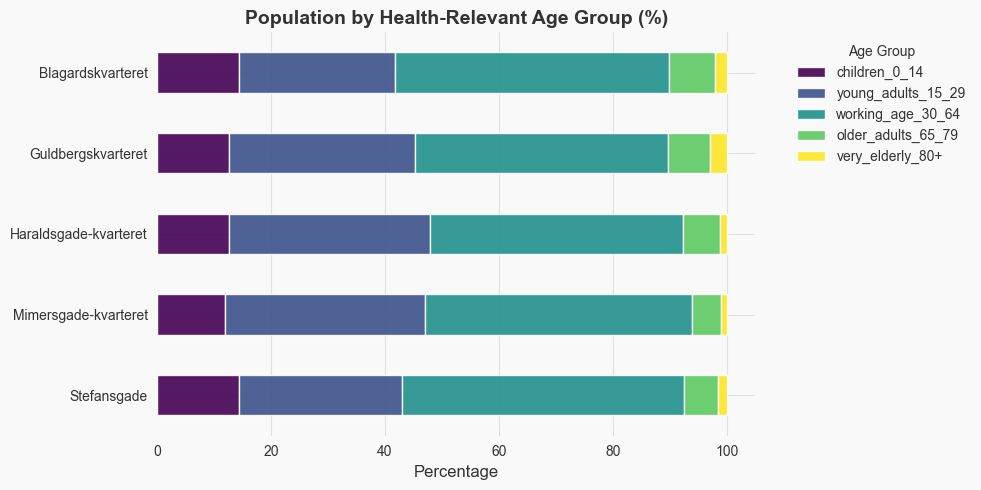

In [6]:
# Visualise: age group proportions per neighbourhood
pop_pct = pop_pivot.drop(columns="total").div(pop_pivot["total"], axis=0) * 100

# Add neighbourhood names for display
hood_names = gdf_hoods.set_index("gm_id")["neighbourhood_name"]
pop_pct.index = pop_pct.index.map(hood_names)

ax = pop_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 5),
    colormap="viridis",
    alpha=0.9,
)
ax.set_title("Population by Health-Relevant Age Group (%)")
ax.set_xlabel("Percentage")
ax.set_ylabel("")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Age Group")
sns.despine()
plt.tight_layout()
plt.show()

In [7]:
# Dwelling stock summary: total units (including vacant) and average unit size
# Compare BBR-only residential area vs all buildings (inflated by KNN)

# Total units per neighbourhood (ALL units including vacant)
total_units = df_dwell.groupby("gm_id")["units"].sum().reset_index()
total_units.columns = ["gm_id", "total_units"]

# Occupied units only (for avg persons per unit)
df_occupied = df_dwell[df_dwell["household_persons"] > 0].copy()
occ_summary = (
    df_occupied.groupby("gm_id")
    .apply(
        lambda g: pd.Series(
            {
                "occupied_units": g["units"].sum(),
                "total_persons": (g["household_persons"] * g["units"]).sum(),
            }
        )
    )
    .reset_index()
)

# BBR-only residential area (official data)
bbr_res = gdf_res[
    (gdf_res["attributes_source"] == "bbr") & (gdf_res["use_category"] == "Residential")
]
bbr_area_by_hood = bbr_res.groupby("gm_id")["residential_area_m2"].sum().reset_index()
bbr_area_by_hood.columns = ["gm_id", "bbr_res_area"]

# All buildings residential area (inflated by KNN)
all_area_by_hood = gdf_res.groupby("gm_id")["residential_area_m2"].sum().reset_index()
all_area_by_hood.columns = ["gm_id", "all_res_area"]

# Combine
dwell_summary = (
    total_units.merge(occ_summary, on="gm_id")
    .merge(bbr_area_by_hood, on="gm_id")
    .merge(all_area_by_hood, on="gm_id")
    .merge(gdf_hoods[["gm_id", "neighbourhood_name"]], on="gm_id")
)
dwell_summary["avg_persons_per_unit"] = (
    dwell_summary["total_persons"] / dwell_summary["occupied_units"]
)
dwell_summary["bbr_unit_size_m2"] = (
    dwell_summary["bbr_res_area"] / dwell_summary["total_units"]
)
dwell_summary["all_unit_size_m2"] = (
    dwell_summary["all_res_area"] / dwell_summary["total_units"]
)

print("Dwelling Stock Summary (total units incl. vacant)")
print("=" * 95)
print(
    dwell_summary[
        [
            "neighbourhood_name",
            "total_units",
            "avg_persons_per_unit",
            "bbr_res_area",
            "bbr_unit_size_m2",
            "all_res_area",
            "all_unit_size_m2",
        ]
    ].to_string(index=False, float_format="{:.1f}".format)
)
print()
print("bbr_unit_size_m2 = BBR-only residential area / total units (official data)")
print("all_unit_size_m2 = all buildings incl. KNN-estimated / total units (inflated)")

Dwelling Stock Summary (total units incl. vacant)
   neighbourhood_name  total_units  avg_persons_per_unit  bbr_res_area  bbr_unit_size_m2  all_res_area  all_unit_size_m2
          Stefansgade         9367                   1.9      691393.0              73.8     1882697.7             201.0
 Mimersgade-kvarteret         9477                   1.9      660734.0              69.7     2138512.8             225.7
Haraldsgade-kvarteret         5584                   1.9      380554.0              68.2     1203926.2             215.6
   Guldbergskvarteret        10930                   1.9      814879.0              74.6     2199532.2             201.2
    Blagardskvarteret         7111                   2.1      597137.0              84.0     1242689.3             174.8

bbr_unit_size_m2 = BBR-only residential area / total units (official data)
all_unit_size_m2 = all buildings incl. KNN-estimated / total units (inflated)


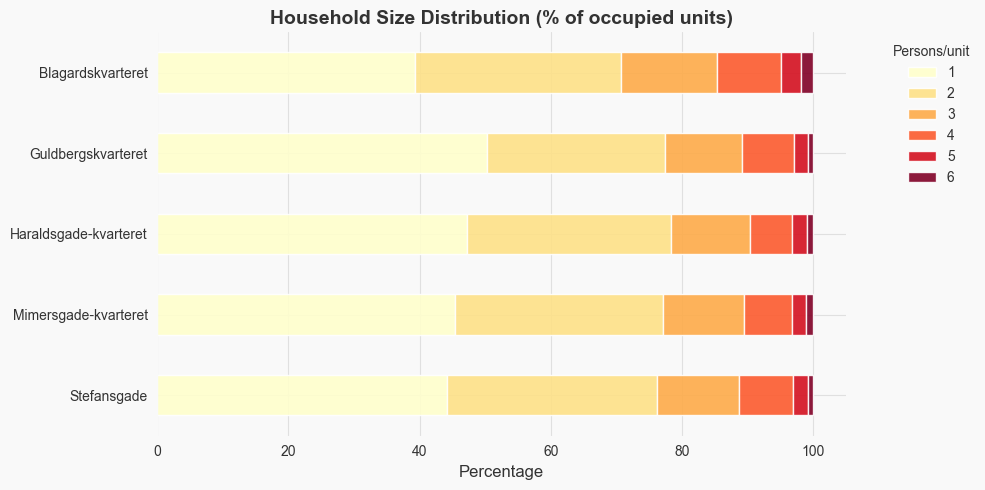

In [8]:
# Household size distribution per neighbourhood (occupied units only)
hh_dist = (
    df_occupied.groupby(["gm_id", "household_persons"])["units"].sum().reset_index()
)
hh_pivot = hh_dist.pivot(
    index="gm_id", columns="household_persons", values="units"
).fillna(0)
hh_pct = hh_pivot.div(hh_pivot.sum(axis=1), axis=0) * 100
hh_pct.index = hh_pct.index.map(hood_names)

ax = hh_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 5),
    colormap="YlOrRd",
    alpha=0.9,
)
ax.set_title("Household Size Distribution (% of occupied units)")
ax.set_xlabel("Percentage")
ax.set_ylabel("")
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Persons/unit",
)
sns.despine()
plt.tight_layout()
plt.show()

### Decision point

Review the outputs above:
1. Do the 5 health-relevant age groups make sense, or should we adjust the breaks?
2. Are the implied average unit sizes reasonable for Copenhagen (~50–80 m²)?
3. How much do neighbourhoods differ in household size mix — does this suggest the area-proportional baseline will miss important variation?

## 2. Baseline Population Estimate (Unit-Count Proportional)

**Weight used:** `antal_boliger` — residential unit count per building from BBR Enhed registry.

Each building gets a share of the neighbourhood's population proportional to its unit count:

```
area_share = building_units / neighbourhood_total_units
pop_age_group = neighbourhood_pop_age_group × area_share
```

**Data quality:**
- **BBR buildings** (`attributes_source == "bbr"`): direct unit counts from the Enhed registry (~1,647 of 1,668 residential buildings)
- **Estimated buildings**: KNN-averaged from 5 nearest BBR neighbours. Median 21 units/building vs BBR median 17 — a small and acceptable inflation
- **Buildings with null `antal_boliger`** (very few): fallback to neighbourhood median of BBR residential buildings

This replaces the previous two-tier area-proportional approach which had a known KNN inflation problem (~200+ m²/unit for estimated buildings).

In [9]:
# Unit-count proportional population distribution
# Weight = antal_boliger (residential units from BBR Enhed + KNN fill)
# For the few buildings with null antal_boliger: use neighbourhood median of BBR residential buildings

# Reload fresh residential buildings from updated integrated layer
gdf_res = gdf_buildings[gdf_buildings["residential_area_m2"] > 0].copy()
print(f"Residential buildings: {len(gdf_res):,}")
print()

# Inspect antal_boliger quality
print("antal_boliger by source:")
print(
    gdf_res.groupby("attributes_source")["antal_boliger"]
    .agg(["count", "median", "mean", "max"])
    .round(1)
)
print()
print("Null counts:")
print(
    gdf_res.groupby("attributes_source")["antal_boliger"].apply(
        lambda x: x.isna().sum()
    )
)
print()

# Fallback for null antal_boliger: neighbourhood median of BBR residential buildings
bbr_res = gdf_res[gdf_res["attributes_source"] == "bbr"]
hood_median_units = bbr_res.groupby("gm_id")["antal_boliger"].median()
print("Neighbourhood median units (BBR-only):")
for gm_id, med in hood_median_units.items():
    print(f"  {hood_names.get(gm_id, gm_id)}: {med:.0f}")
print()

gdf_res["unit_weight"] = gdf_res["antal_boliger"].copy()
null_mask = gdf_res["unit_weight"].isna()
for gm_id, med in hood_median_units.items():
    mask = null_mask & (gdf_res["gm_id"] == gm_id)
    gdf_res.loc[mask, "unit_weight"] = med

n_fallback = null_mask.sum()
print(
    f"Buildings using fallback median: {n_fallback} ({n_fallback / len(gdf_res) * 100:.1f}%)"
)

# Calculate unit share within each neighbourhood
hood_unit_totals = (
    gdf_res.groupby("gm_id")["unit_weight"].sum().rename("hood_unit_total")
)
gdf_res = gdf_res.merge(hood_unit_totals, on="gm_id", how="left")
gdf_res["unit_share"] = gdf_res["unit_weight"] / gdf_res["hood_unit_total"]

# Distribute each age group's population proportionally
for ag in AGE_GROUP_LABELS:
    ag_pop = pop_by_group[pop_by_group["age_group"] == ag].set_index("gm_id")["people"]
    gdf_res[f"pop_{ag}"] = gdf_res["gm_id"].map(ag_pop) * gdf_res["unit_share"]

pop_cols = [f"pop_{ag}" for ag in AGE_GROUP_LABELS]
gdf_res["pop_total"] = gdf_res[pop_cols].sum(axis=1)

print(f"\nTotal estimated population: {gdf_res['pop_total'].sum():,.0f}")
print(f"Expected from CSV:          {df_pop['people'].sum():,}")
print()

source_summary = (
    gdf_res.groupby("attributes_source")
    .agg(
        n_buildings=("pop_total", "count"),
        pop_total=("pop_total", "sum"),
        median_units=("unit_weight", "median"),
        median_pop=("pop_total", "median"),
    )
    .round(1)
)
print("Population by data source:")
print(source_summary.to_string())

Residential buildings: 3,661

antal_boliger by source:
                   count  median  mean    max
attributes_source                            
bbr                 1647    17.0  25.6  510.0
estimated           1978    21.0  39.3  410.0

Null counts:
attributes_source
bbr          22
estimated    14
Name: antal_boliger, dtype: int64

Neighbourhood median units (BBR-only):
  Stefansgade: 20
  Mimersgade-kvarteret: 19
  Haraldsgade-kvarteret: 12
  Guldbergskvarteret: 16
  Blagardskvarteret: 13

Buildings using fallback median: 36 (1.0%)

Total estimated population: 79,753
Expected from CSV:          79,753

Population by data source:
                   n_buildings  pop_total  median_units  median_pop
attributes_source                                                  
bbr                       1669    29048.6          17.0        11.3
estimated                 1992    50704.4          21.0        14.2


In [10]:
# Validation: check totals match per neighbourhood per age group
validation = gdf_res.groupby("gm_id")[pop_cols + ["pop_total"]].sum().round(1)
validation = validation.merge(
    pop_pivot[["total"]].rename(columns={"total": "csv_total"}),
    left_index=True,
    right_index=True,
)
validation["diff"] = validation["pop_total"] - validation["csv_total"]
validation.index = validation.index.map(hood_names)
print("Validation: estimated vs CSV totals per neighbourhood")
print(
    validation[["pop_total", "csv_total", "diff"]].to_string(
        float_format="{:.0f}".format
    )
)

Validation: estimated vs CSV totals per neighbourhood
                       pop_total  csv_total  diff
gm_id                                            
Stefansgade                17754      17754     0
Mimersgade-kvarteret       17372      17372     0
Haraldsgade-kvarteret      10188      10188     0
Guldbergskvarteret         19761      19761     0
Blagardskvarteret          14678      14678     0


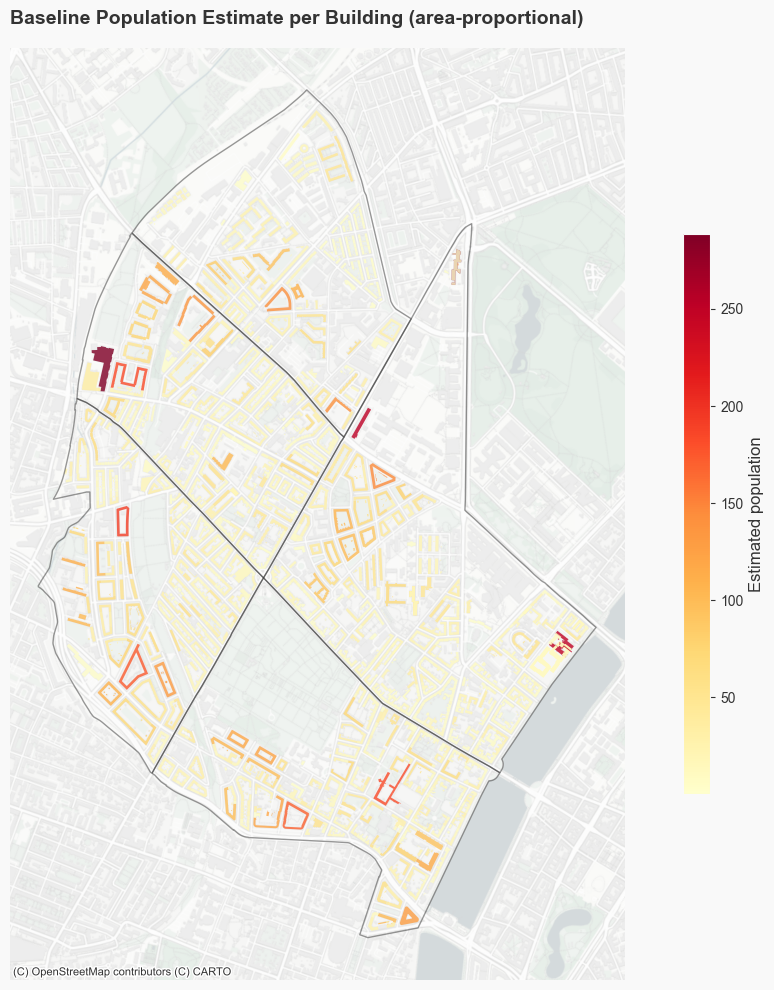

In [11]:
# Visualise: total estimated population per building (map)
fig, ax = plt.subplots(figsize=(12, 10))

gdf_res.plot(
    column="pop_total",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Estimated population", "shrink": 0.6},
    edgecolor="none",
    ax=ax,
    alpha=0.8,
)

# Neighbourhood outlines
gdf_hoods.boundary.plot(ax=ax, color=style.PALETTE["text"], linewidth=1, alpha=0.5)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")
ax.set_title(
    "Baseline Population Estimate per Building (area-proportional)", loc="left"
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_23335/2479390148.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", title="Dominant group")
/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_23335/2479390148.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right", title="Dominant group")


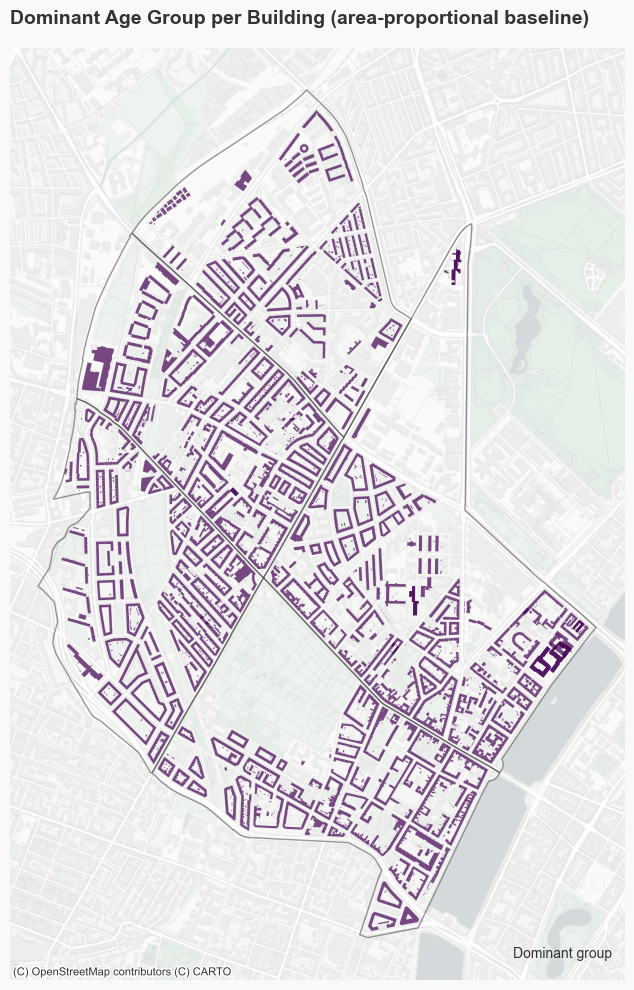

In [12]:
# Visualise: dominant age group per building
gdf_res["dominant_group"] = gdf_res[pop_cols].idxmax(axis=1).str.replace("pop_", "")

fig, ax = plt.subplots(figsize=(12, 10))

# Color by dominant age group
groups = gdf_res["dominant_group"].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(groups)))
color_map = dict(zip(sorted(groups), colors))

for group, color in color_map.items():
    mask = gdf_res["dominant_group"] == group
    gdf_res[mask].plot(ax=ax, color=color, alpha=0.7, edgecolor="none", label=group)

gdf_hoods.boundary.plot(ax=ax, color=style.PALETTE["text"], linewidth=1, alpha=0.5)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")
ax.set_title("Dominant Age Group per Building (area-proportional baseline)", loc="left")
ax.legend(loc="lower right", title="Dominant group")
ax.set_axis_off()
plt.tight_layout()
plt.show()

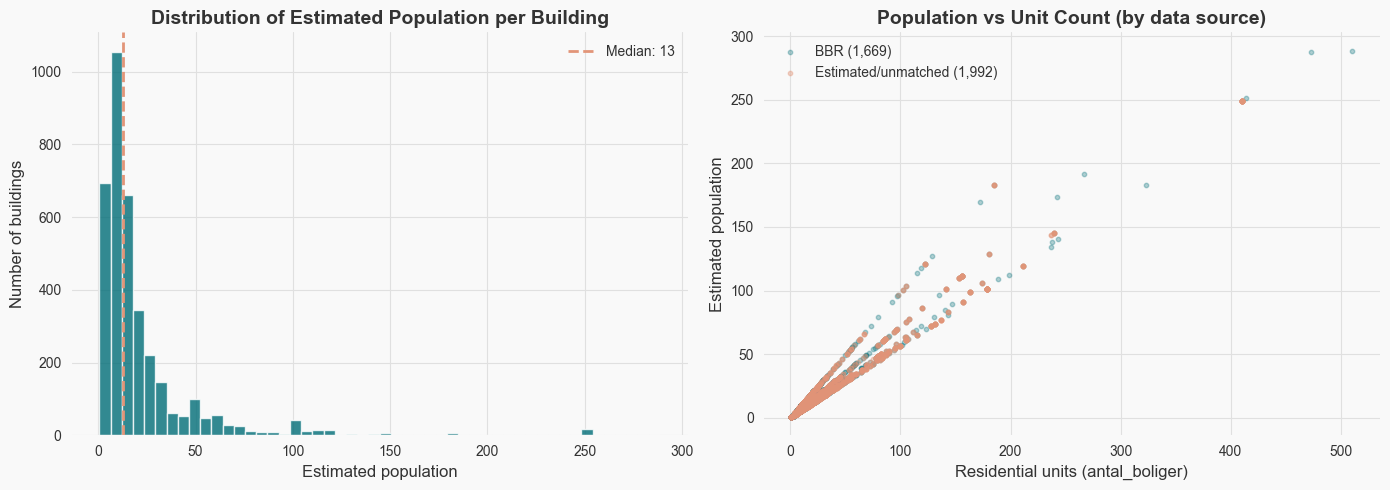

In [13]:
# Distribution of estimated population per building
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(
    gdf_res["pop_total"],
    bins=50,
    color=style.PALETTE["brand"],
    alpha=0.8,
    edgecolor="white",
)
axes[0].set_title("Distribution of Estimated Population per Building")
axes[0].set_xlabel("Estimated population")
axes[0].set_ylabel("Number of buildings")
axes[0].axvline(
    gdf_res["pop_total"].median(),
    color=style.PALETTE["accent_warm"],
    ls="--",
    label=f"Median: {gdf_res['pop_total'].median():.0f}",
)
axes[0].legend()

# Population vs unit count — colored by data source
bbr_mask = gdf_res["attributes_source"] == "bbr"
est_mask = ~bbr_mask

axes[1].scatter(
    gdf_res.loc[bbr_mask, "unit_weight"],
    gdf_res.loc[bbr_mask, "pop_total"],
    alpha=0.3,
    s=10,
    color=style.PALETTE["brand"],
    label=f"BBR ({bbr_mask.sum():,})",
)
axes[1].scatter(
    gdf_res.loc[est_mask, "unit_weight"],
    gdf_res.loc[est_mask, "pop_total"],
    alpha=0.4,
    s=10,
    color=style.PALETTE["accent_warm"],
    label=f"Estimated/unmatched ({est_mask.sum():,})",
)
axes[1].set_title("Population vs Unit Count (by data source)")
axes[1].set_xlabel("Residential units (antal_boliger)")
axes[1].set_ylabel("Estimated population")
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

### Decision point

Review the baseline:
1. Does the total population validation check out (difference should be ~0)?
2. Does the scatter plot now show a single clean ascending pattern? BBR (blue) and estimated (orange) should both follow the same trend — if the orange cluster is still flat, KNN isn't filling well
3. The dominant age group map will still show all buildings in a neighbourhood having the same dominant group (working age) — this is a **known limitation of area/unit proportional distribution**. It will be addressed in Section 3 with construction-era age profile modifiers
4. Are the population-per-building magnitudes reasonable? (median building should have ~20 people if median is 17 units × ~2.3 persons/unit)

## 3. Dwelling Typology Age-Profile Adjustment

The baseline (Section 2) distributes population proportionally to unit count — every building in a neighbourhood gets the **same age profile**. A 5-storey pre-war tenement and a 1-storey courtyard annex both show ~28% young adults, ~45% working age, etc.

This section breaks that uniformity using **average unit size** as a proxy for household type:

| Tier | Avg m²/unit | Likely occupant | Age signal |
|---|---|---|---|
| `studio` | ≤ 50 | 1-person: singles, students, elderly alone | young adults ↑, children ↓ |
| `small` | 50–80 | 1–2 person: young couples, young professionals | working age ↑ |
| `medium` | 80–110 | 2–3 person: established couples, small families | working age, some children |
| `family` | > 110 | 3–4 person: families with children | children ↑, young adults ↓ |

**Method:** For each building, compute a per-age-group weight by marginalizing over household sizes:

`age_weight[b, a] = Σ_hs  P(hs | tier(b))  ×  P(age_group | hs)`

Then normalize within each neighbourhood × age group so totals still equal the CSV exactly (pycnophylactic constraint preserved).

In [14]:
# Compute average unit size per building and classify into dwelling typology tiers

gdf_res["avg_unit_m2"] = gdf_res["residential_area_m2"] / gdf_res["unit_weight"].clip(
    lower=1
)

TIER_BOUNDS = {"studio": 50, "small": 80, "medium": 110}


def classify_tier(m2):
    if m2 <= TIER_BOUNDS["studio"]:
        return "studio"
    elif m2 <= TIER_BOUNDS["small"]:
        return "small"
    elif m2 <= TIER_BOUNDS["medium"]:
        return "medium"
    else:
        return "family"


gdf_res["dwelling_typology"] = gdf_res["avg_unit_m2"].apply(classify_tier)

# Distribution across tiers
tier_dist = (
    gdf_res.groupby("dwelling_typology", observed=False)
    .agg(
        buildings=("building_id", "count"),
        total_units=("unit_weight", "sum"),
        median_unit_m2=("avg_unit_m2", "median"),
    )
    .reindex(["studio", "small", "medium", "family"])
)
tier_dist["pct_buildings"] = (tier_dist["buildings"] / len(gdf_res) * 100).round(1)
tier_dist["pct_units"] = (
    tier_dist["total_units"] / tier_dist["total_units"].sum() * 100
).round(1)

print("Dwelling typology tier distribution:")
print(tier_dist.to_string())
print()
print(f"avg_unit_m2 summary:")
print(gdf_res["avg_unit_m2"].describe().round(1))

Dwelling typology tier distribution:
                   buildings   total_units  median_unit_m2  pct_buildings  pct_units
dwelling_typology                                                                   
studio                    89  14329.000000       43.000000            2.4       11.9
small                    790  68485.400000       69.203297           21.6       56.9
medium                   561  34039.516667       88.333333           15.3       28.3
family                   229   3605.216667      134.250000            6.3        3.0

avg_unit_m2 summary:
count    3661.0
mean       82.7
std        41.2
min         1.9
25%        66.3
50%        77.6
75%        89.9
max      1077.2
Name: avg_unit_m2, dtype: float64


In [15]:
# Define P(household_size | tier) prior and calibrate against the dwellings CSV
#
# TIER_TO_HS encodes: given a building's average unit size, what mix of
# 1-person / 2-person / 3-person / 4+-person households does it likely contain?
# Values are probabilities that sum to 1.0 per tier.

TIER_TO_HS = {
    "studio": {
        1: 0.90,
        2: 0.07,
        3: 0.02,
        "4+": 0.01,
    },  # minimal change: token 4+ for roommates/edge cases
    "small": {
        1: 0.52,
        2: 0.32,
        3: 0.10,
        "4+": 0.06,
    },  # 4+: 0.02 → 0.06; 2p down; urban immigrant families
    "medium": {
        1: 0.12,
        2: 0.40,
        3: 0.28,
        "4+": 0.20,
    },  # 4+: 0.10 → 0.20; realistic for 80-110m² family flats
    "family": {
        1: 0.03,
        2: 0.15,
        3: 0.32,
        "4+": 0.50,
    },  # 4+: 0.40 → 0.50; >110m² strongly family-oriented
}


# Compute model-implied household-size distribution per neighbourhood
# Each building contributes: TIER_TO_HS[tier][hs] × unit_weight units in each hs category
for hs in [1, 2, 3, "4+"]:
    col = f"hs_prob_{hs}"
    gdf_res[col] = gdf_res["dwelling_typology"].map(
        {t: TIER_TO_HS[t][hs] for t in TIER_TO_HS}
    )

hs_cols = {hs: f"hs_implied_{hs}" for hs in [1, 2, 3, "4+"]}
for hs in [1, 2, 3, "4+"]:
    gdf_res[hs_cols[hs]] = gdf_res[f"hs_prob_{hs}"] * gdf_res["unit_weight"]

hs_model = gdf_res.groupby("gm_id")[[v for v in hs_cols.values()]].sum()
hs_model.columns = [1, 2, 3, "4+"]

# Dwellings CSV: occupied units (household_persons > 0) grouped to same categories
df_occupied = df_dwell[df_dwell["household_persons"] > 0].copy()
df_occupied["hs_group"] = df_occupied["household_persons"].apply(
    lambda x: "4+" if x >= 4 else x
)
csv_hs = df_occupied.groupby(["gm_id", "hs_group"])["units"].sum().unstack(fill_value=0)
csv_hs.columns = [int(c) if isinstance(c, int) else c for c in csv_hs.columns]

# Side-by-side comparison
print("Calibration: Model-implied vs Dwellings CSV household-size distribution")
print("=" * 75)
for gm_id in sorted(gdf_res["gm_id"].unique()):
    name = hood_names.get(gm_id, str(gm_id))
    model_row = hs_model.loc[gm_id] if gm_id in hs_model.index else None
    csv_row = csv_hs.loc[gm_id] if gm_id in csv_hs.index else None
    total_m = model_row.sum() if model_row is not None else 0
    total_c = csv_row.sum() if csv_row is not None else 0
    print(f"\n{name[:50]} (gm_id={gm_id})")
    print(f"  {'HS':5s}  {'Model':>8s}  {'Model%':>7s}  {'CSV':>8s}  {'CSV%':>7s}")
    for hs in [1, 2, 3, "4+"]:
        m = model_row[hs] if model_row is not None else 0
        c = csv_row.get(hs, 0) if csv_row is not None else 0
        print(
            f"  {str(hs):5s}  {m:>8.0f}  {m / total_m * 100:>6.1f}%  {c:>8.0f}  {c / total_c * 100:>6.1f}%"
        )
print()
print("NOTE: Adjust TIER_TO_HS priors above if any category is off by more than 10pp.")

Calibration: Model-implied vs Dwellings CSV household-size distribution

Stefansgade (gm_id=1)
  HS        Model   Model%       CSV     CSV%
  1          9729    39.3%      4032    44.2%
  2          8303    33.5%      2915    32.0%
  3          3952    15.9%      1148    12.6%
  4+         2794    11.3%      1026    11.2%

Mimersgade-kvarteret (gm_id=2)
  HS        Model   Model%       CSV     CSV%
  1         13608    44.3%      4026    45.3%
  2          9982    32.5%      2819    31.7%
  3          4262    13.9%      1098    12.4%
  4+         2849     9.3%       938    10.6%

Haraldsgade-kvarteret (gm_id=3)
  HS        Model   Model%       CSV     CSV%
  1          8539    48.6%      2558    47.2%
  2          5344    30.4%      1689    31.1%
  3          2236    12.7%       656    12.1%
  4+         1467     8.3%       522     9.6%

Guldbergskvarteret (gm_id=4)
  HS        Model   Model%       CSV     CSV%
  1         16138    49.6%      5161    50.3%
  2          8609    26.5%  

In [ ]:
# Define P(age_group | household_size) prior matrix
#
# Based on Danish/Nordic urban apartment demographics.
# Each row sums to 1.0.
#
# Key calibration rationale:
# - 1-person: in dense urban Nørrebro, single-person apartments are overwhelmingly
#   occupied by students and young professionals (15-29). The 30-64 single living
#   alone in a studio here is atypical → young_adults 0.65, working_age 0.25.
# - 2-person: couples are mostly 30+; some young couples → working_age dominates
# - 3-person: 1 child + 2 parents (ages 30-45) → strong working_age, meaningful children
# - 4+-person: 2+ children + parents → children rise, working_age stays central

HS_TO_AGE = {
    1: {
        "children_0_14": 0.00,
        "young_adults_15_29": 0.65,
        "working_age_30_64": 0.25,
        "older_adults_65_79": 0.08,
        "very_elderly_80+": 0.02,
    },
    2: {
        "children_0_14": 0.03,
        "young_adults_15_29": 0.22,
        "working_age_30_64": 0.57,
        "older_adults_65_79": 0.15,
        "very_elderly_80+": 0.03,
    },
    3: {
        "children_0_14": 0.22,
        "young_adults_15_29": 0.15,
        "working_age_30_64": 0.52,
        "older_adults_65_79": 0.09,
        "very_elderly_80+": 0.02,
    },
    "4+": {
        "children_0_14": 0.35,
        "young_adults_15_29": 0.10,
        "working_age_30_64": 0.47,
        "older_adults_65_79": 0.07,
        "very_elderly_80+": 0.01,
    },
}

# Derived age-profile weight per building:  age_weight[b, a] = Σ_hs P(hs|tier) × P(age|hs)
# This is a dot product of the two prior tables, vectorized per building.
for ag in AGE_GROUP_LABELS:
    ag_key = ag  # matches keys in HS_TO_AGE
    gdf_res[f"age_weight_{ag}"] = sum(
        gdf_res[f"hs_prob_{hs}"] * HS_TO_AGE[hs][ag_key] for hs in [1, 2, 3, "4+"]
    )

# Display effective age profile per tier (aggregate check)
print("Effective age-profile weight per tier (Σ P(hs|tier) × P(age|hs)):")
print(f"{'Tier':10s}", end="")
for ag in AGE_GROUP_LABELS:
    print(f"  {ag.split('_')[0]:>10s}", end="")
print()
for tier in ["studio", "small", "medium", "family"]:
    mask = gdf_res["dwelling_typology"] == tier
    print(f"{tier:10s}", end="")
    for ag in AGE_GROUP_LABELS:
        w = gdf_res.loc[mask, f"age_weight_{ag}"].mean()
        print(f"  {w:>10.3f}", end="")
    print()
print()
print(
    "Expected pattern: studio → young_adults dominant; family → working_age with children rising"
)
print(
    "working_age range across tiers should now be ~0.28 (studio) to ~0.50 (medium/family)"
)

Effective age-profile weight per tier (Σ P(hs|tier) × P(age|hs)):
Tier          children       young     working       older        very
studio           0.010       0.604       0.280       0.085       0.021
small            0.053       0.429       0.393       0.103       0.023
medium           0.144       0.228       0.498       0.109       0.022
family           0.250       0.151       0.494       0.089       0.017

Expected pattern: studio → young_adults dominant; family → working_age with children rising
working_age range across tiers should now be ~0.28 (studio) to ~0.50 (medium/family)


In [17]:
# Pycnophylactic redistribution: combine unit share with age-profile weight,
# normalize within each neighbourhood × age group so totals exactly match the CSV.
#
# For building b, neighbourhood n, age group a:
#   adj_weight[b,a] = unit_share[b] × age_weight[b,a]
#   pop[b,a] = P_csv[n,a] × adj_weight[b,a] / Σ_{b in n} adj_weight[b,a]

for ag in AGE_GROUP_LABELS:
    adj_col = f"adj_weight_{ag}"
    gdf_res[adj_col] = gdf_res["unit_share"] * gdf_res[f"age_weight_{ag}"]
    # Normalize within neighbourhood
    norm_denom = gdf_res.groupby("gm_id")[adj_col].transform("sum")
    norm_share = gdf_res[adj_col] / norm_denom
    # Scale to neighbourhood CSV total
    ag_pop = pop_by_group[pop_by_group["age_group"] == ag].set_index("gm_id")["people"]
    gdf_res[f"pop_{ag}"] = gdf_res["gm_id"].map(ag_pop) * norm_share

pop_cols = [f"pop_{ag}" for ag in AGE_GROUP_LABELS]
gdf_res["pop_total"] = gdf_res[pop_cols].sum(axis=1)
gdf_res["dominant_group"] = gdf_res[pop_cols].idxmax(axis=1).str.replace("pop_", "")

# Validate: check totals match per neighbourhood × age group
print("Validation — Σ_buildings pop[b,a]  vs  P_csv[n,a]")
print(f"{'Age group':35s}  {'Max |diff|':>12s}  {'Status':>8s}")
all_ok = True
for ag in AGE_GROUP_LABELS:
    hood_sum = gdf_res.groupby("gm_id")[f"pop_{ag}"].sum()
    csv_total = pop_by_group[pop_by_group["age_group"] == ag].set_index("gm_id")[
        "people"
    ]
    diff = (hood_sum - csv_total).abs().max()
    ok = diff < 1e-6
    all_ok = all_ok and ok
    print(f"  {ag:35s}  {diff:>12.8f}  {'OK' if ok else 'FAIL':>8s}")

print()
if all_ok:
    print(
        "✓ All neighbourhood × age group totals preserved exactly (pycnophylactic constraint met)"
    )
else:
    print("✗ Some totals are off — check normalization logic above")

print()
print(f"Total estimated population: {gdf_res['pop_total'].sum():,.0f}")
print(f"Expected from CSV:          {df_pop['people'].sum():,}")

Validation — Σ_buildings pop[b,a]  vs  P_csv[n,a]
Age group                              Max |diff|    Status
  children_0_14                          0.00000000        OK
  young_adults_15_29                     0.00000000        OK
  working_age_30_64                      0.00000000        OK
  older_adults_65_79                     0.00000000        OK
  very_elderly_80+                       0.00000000        OK

✓ All neighbourhood × age group totals preserved exactly (pycnophylactic constraint met)

Total estimated population: 79,753
Expected from CSV:          79,753


/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_23335/599296289.py:34: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", title="Tier")
/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_23335/599296289.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right", title="Tier")
/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/ipykernel_23335/599296289.py:52: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", title="Dominant group", fontsize=8)
/var/folders/j6/ft69qsf979gflgtqf862qt000000gs/T/

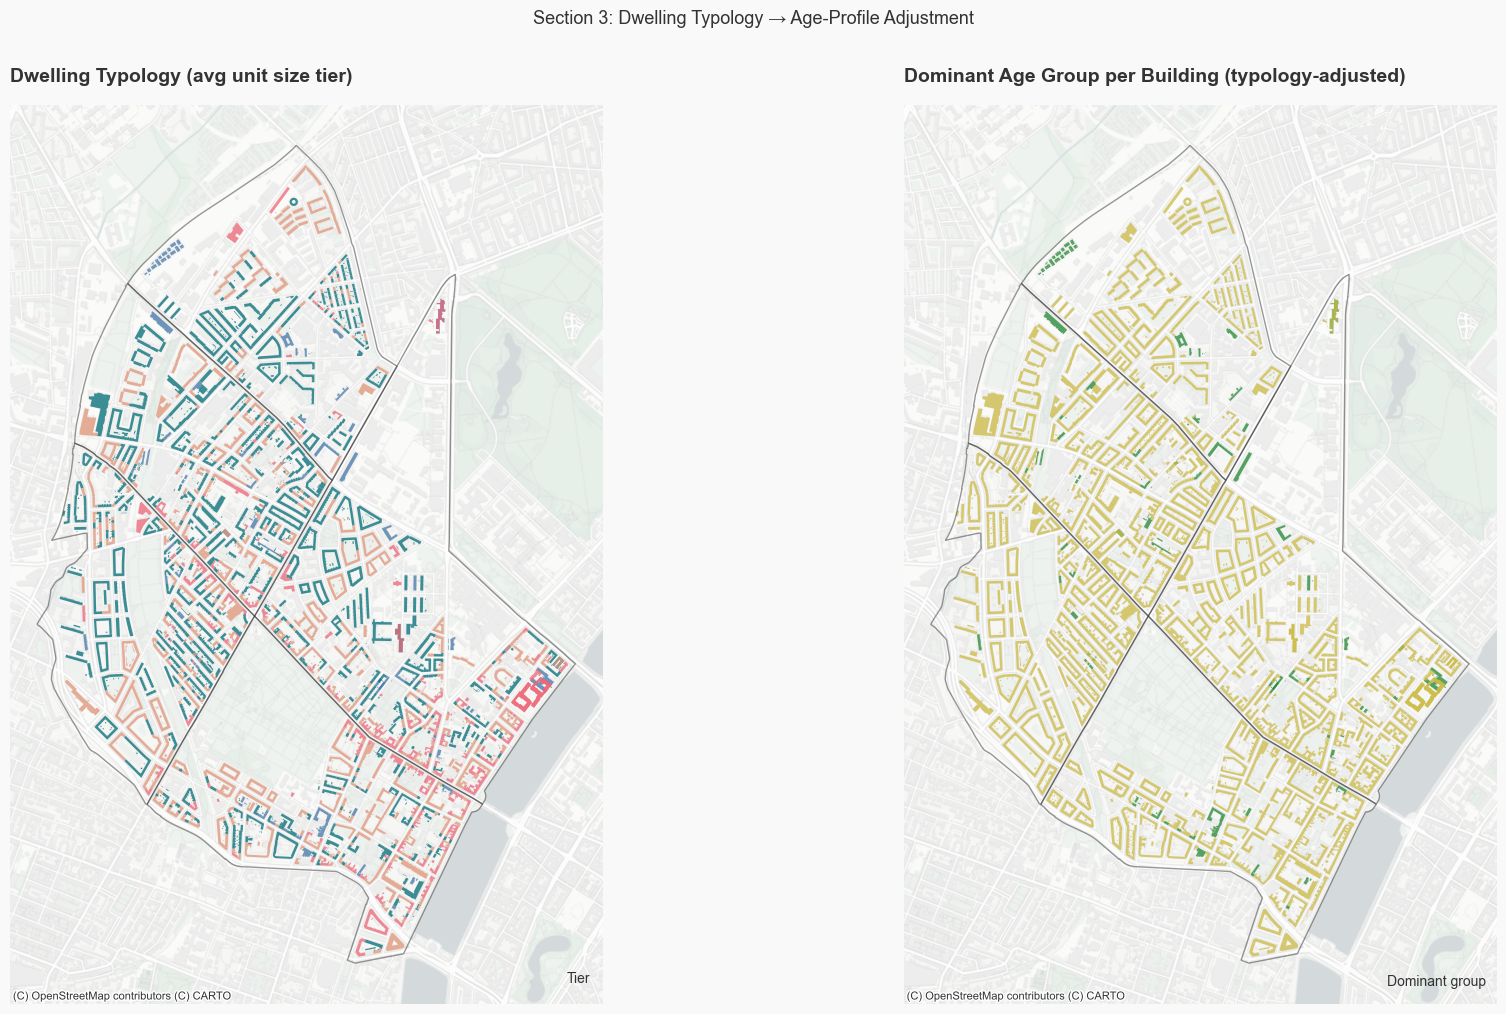


Dominant age group by dwelling tier:
dominant_group     working_age_30_64  young_adults_15_29
dwelling_typology                                       
studio                             0                 214
small                           1860                   0
medium                          1222                   0
family                           365                   0


In [18]:
# Visualise: dominant age group per building — now with within-neighbourhood variation
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

TIER_COLORS = {
    "studio": style.PALETTE.get("accent_cool", "#4477AA"),
    "small": style.PALETTE.get("brand", "#44BB99"),
    "medium": style.PALETTE.get("accent_warm", "#CCBB44"),
    "family": style.PALETTE.get("highlight", "#EE6677"),
}

GROUP_COLORS = {
    "children_0_14": "#4477AA",
    "young_adults_15_29": "#228833",
    "working_age_30_64": "#CCBB44",
    "older_adults_65_79": "#EE6677",
    "very_elderly_80+": "#AA3377",
}

# Left map: dwelling typology (tier)
ax = axes[0]
for tier, color in TIER_COLORS.items():
    mask = gdf_res["dwelling_typology"] == tier
    if mask.sum() > 0:
        gdf_res[mask].plot(
            ax=ax,
            color=color,
            alpha=0.75,
            edgecolor="none",
            label=f"{tier} ({mask.sum():,})",
        )
gdf_hoods.boundary.plot(ax=ax, color=style.PALETTE["text"], linewidth=1, alpha=0.5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")
ax.set_title("Dwelling Typology (avg unit size tier)", loc="left")
ax.legend(loc="lower right", title="Tier")
ax.set_axis_off()

# Right map: dominant age group (typology-adjusted)
ax = axes[1]
for group, color in GROUP_COLORS.items():
    mask = gdf_res["dominant_group"] == group
    if mask.sum() > 0:
        gdf_res[mask].plot(
            ax=ax,
            color=color,
            alpha=0.75,
            edgecolor="none",
            label=f"{group} ({mask.sum():,})",
        )
gdf_hoods.boundary.plot(ax=ax, color=style.PALETTE["text"], linewidth=1, alpha=0.5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")
ax.set_title("Dominant Age Group per Building (typology-adjusted)", loc="left")
ax.legend(loc="lower right", title="Dominant group", fontsize=8)
ax.set_axis_off()

plt.suptitle(
    "Section 3: Dwelling Typology → Age-Profile Adjustment", fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# Summary of dominant group by tier
print("\nDominant age group by dwelling tier:")
print(
    gdf_res.groupby(["dwelling_typology", "dominant_group"])
    .size()
    .unstack(fill_value=0)
    .reindex(["studio", "small", "medium", "family"])
    .to_string()
)

### Decision point

Review Section 3 outputs:

1. **Calibration table (cell above)**: Do the model-implied household-size percentages broadly match the dwellings CSV? An offset of ±10pp is acceptable — if larger, adjust `TIER_TO_HS` priors and re-run.

2. **Dominant age group map**: Does the right-hand map now show variation *within* each neighbourhood? Studios and small units should skew green (young adults); larger units should show more yellow (working age) or pink (older adults). If the map still looks uniform, the tier distribution may be too homogeneous (check the tier table in the first code cell).

3. **Dominant-group-by-tier table**: Studios should skew `young_adults_15_29` as their top group; family tier should shift toward `working_age_30_64` (with meaningful `children_0_14` contribution). If a tier is dominated by an unexpected group, revisit the `HS_TO_AGE` priors.

4. **Known remaining limitation**: The model cannot resolve age profiles below the tier level. Two 65 m² buildings with identical unit counts will have identical age profiles even if one is occupied by elderly long-term tenants and the other by students. Construction era (Route A from the earlier analysis) would add a second signal to differentiate these — this is a natural Section 4 extension.

**Output schema produced by Section 3:**

| Column | Description |
|---|---|
| `avg_unit_m2` | Residential floor area / unit count |
| `dwelling_typology` | `studio` / `small` / `medium` / `family` |
| `pop_children_0_14` … `pop_very_elderly_80+` | Typology-adjusted population per age group |
| `pop_total` | Sum of age group populations |
| `dominant_group` | Age group with highest estimated population |

These columns are ready for the CitySeer accessibility analysis (Phase 3).